# 对数据异常值检测的探索
## 探索背景
绘制财政自给率与个人储蓄率时序折线图发现异常数值
## 异常值发现过程
1. 计算核心指标，合并数据
   1. 财政自给率 = 收入 / 支出 × 100%（反映政府财政自主能力）
   2. 个人储蓄率 = 存款 / GDP × 100%（反映居民储蓄相对经济规模的水平
2. 分城市绘制两个指标的趋势折线图
3. 找出趋势变异点，核实数据。
![南宁异常](output/南宁异常.png)
![太原异常](output/太原异常.png)
![拉萨异常](output/拉萨异常.png)
![海口异常](output/海口异常.png)

## 异常值发现结果
- 异常值  


| 城市 | 年份 | 收入 | 支出 | 存款 |
| :--- | ---: | ---: | ---: | ---: |
| 南宁 | 2008 | <font color="red">191.17</font> | 166.08 | <font color="red">88.65</font> |
| 太原 | 2007 | 88.42 | <font color="red">155.80</font> | 1307.24 |
| 拉萨 | 2014 | 64.79 | 169.49 | <font color="red">559.28</font> |
| 海口 | 2007 | <font color="red">44.85</font> | 43.21 | 430.95 |
| 海口 | 2017 | 125.36 | 198.32 | <font color="red">3790.10</font> |



经查询城市统计公报核实，异常值正确的数值如下：    
- 住户存款余额：
  - 2017年海口：个人存款余额1576.09亿元（原数据：3790.1）
  - 2014年拉萨：个人储蓄存款余额303.05亿元（原数据：559.28）
  - 2008年南宁：城乡居民储蓄存款余额888.65亿元（原数据：88.65）
- 一般预算收入：
  - 2008年南宁：地方财政一般预算收入92.88亿元（原数据：191.17）
  - 2007年海口：一般预算收入24.35亿元（原数据：44.85）
  - 2007年太原：全年执行一般预算支出115.65亿元（原数据：155.8）

- 更正结果：  

| 城市 | 年份 | 收入 | 支出 | 存款 |
| :--- | ---: | ---: | ---: | ---: |
| 南宁 | 2008 | <font color="green">92.88</font> | 166.08 | <font color="green">888.65</font> |
| 太原 | 2007 | 88.42 | <font color="green">115.65</font> | 1307.24 |
| 拉萨 | 2014 | 64.79 | 169.49 | <font color="green">303.05</font> |
| 海口 | 2007 | <font color="green">24.35</font> | 43.21 | 430.95 |
| 海口 | 2017 | 125.36 | 198.32 | <font color="green">1576.09</font> |
## 探索其他检验方法找异常值
- KNN方法：未找到异常值
- IQR方法：找到8个异常值（上海2024年存款、南京2024年存款、厦门2024年存款、合肥2024年存款、大连2006年收入、大连2006年GDP、宁波2024年存款、杭州2024年存款），但均位于在区间头或尾，实际数据正确。
- Z-score方法：未找到异常值
- Moving Average方法：未找到异常值

✅ 数据df已加载成功！数据形状： (684, 6)
                年份           收入           支出            存款           GDP
count   684.000000   684.000000   684.000000    684.000000    684.000000
mean   2015.000000   895.285219  1199.533670   6935.635775   8096.285117
std       5.481234  1238.984447  1527.399479   8555.346408   8531.657210
min    2006.000000     3.900000    15.690000     78.990000    102.390000
25%    2010.000000   218.915000   341.292500   2018.815000   2600.690000
50%    2015.000000   461.320000   728.885000   4156.625000   5479.550000
75%    2020.000000  1013.392500  1340.912500   8507.737500  10573.702500
max    2024.000000  8374.170000  9874.840000  70398.150000  53759.500000


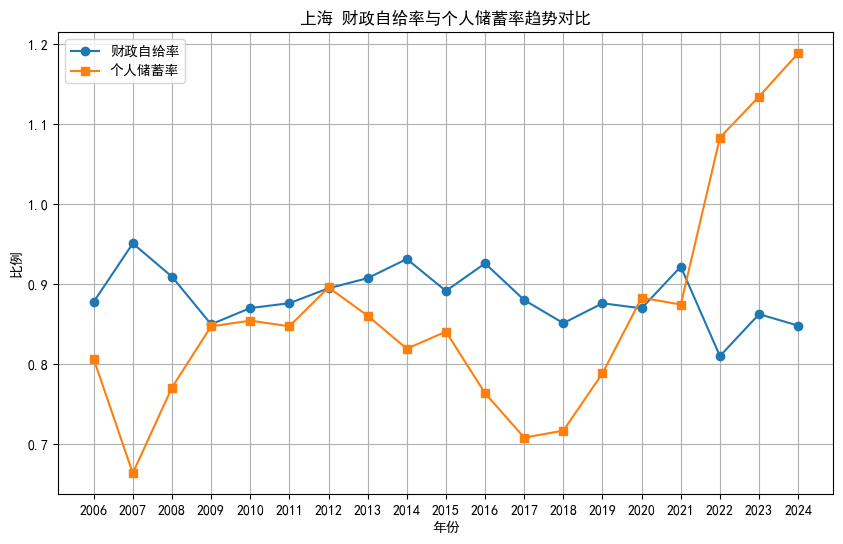

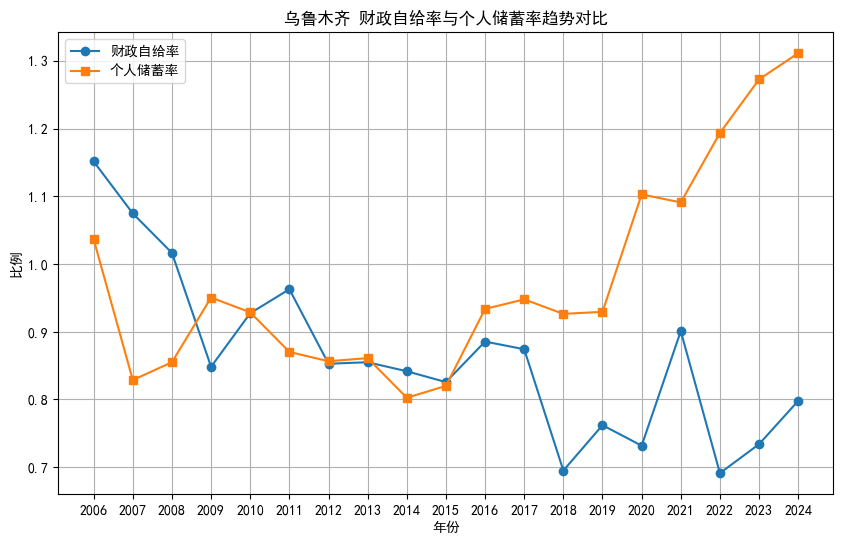

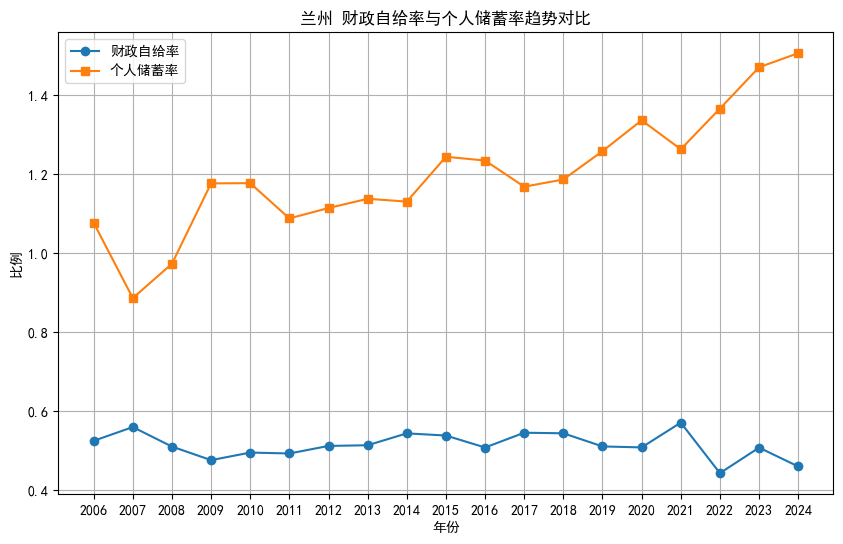

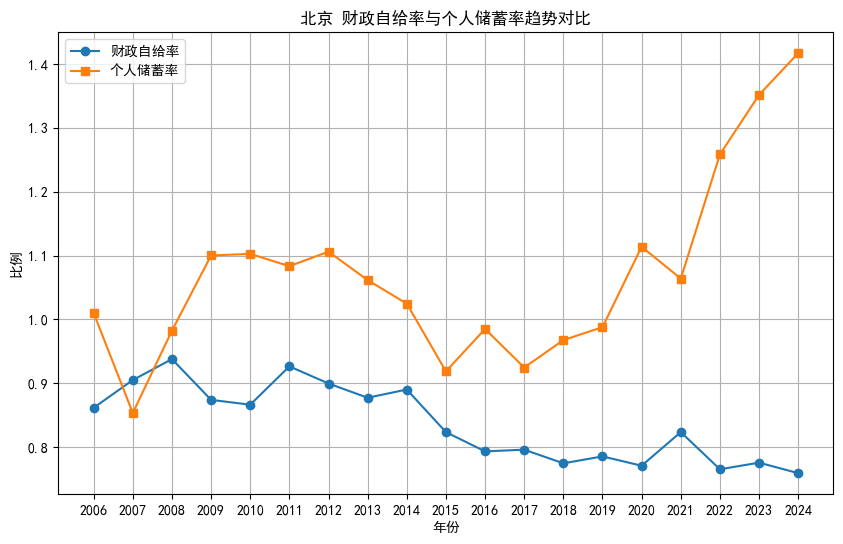

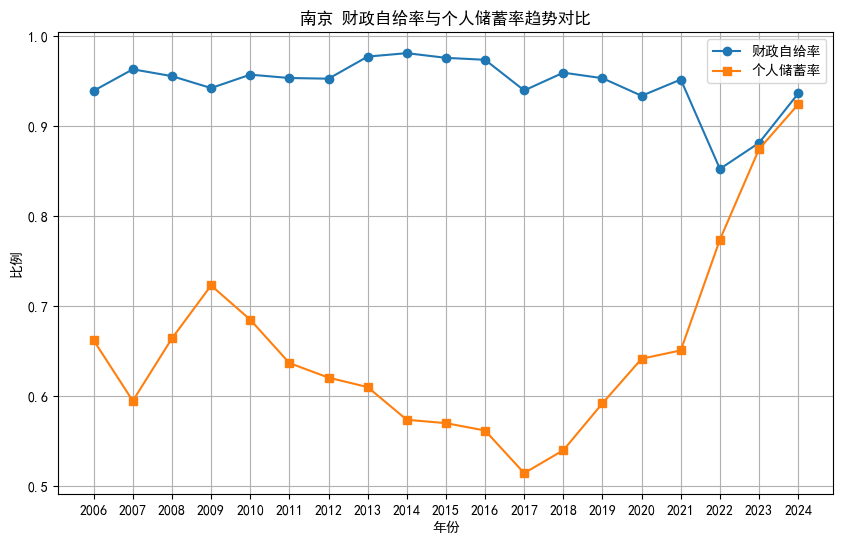

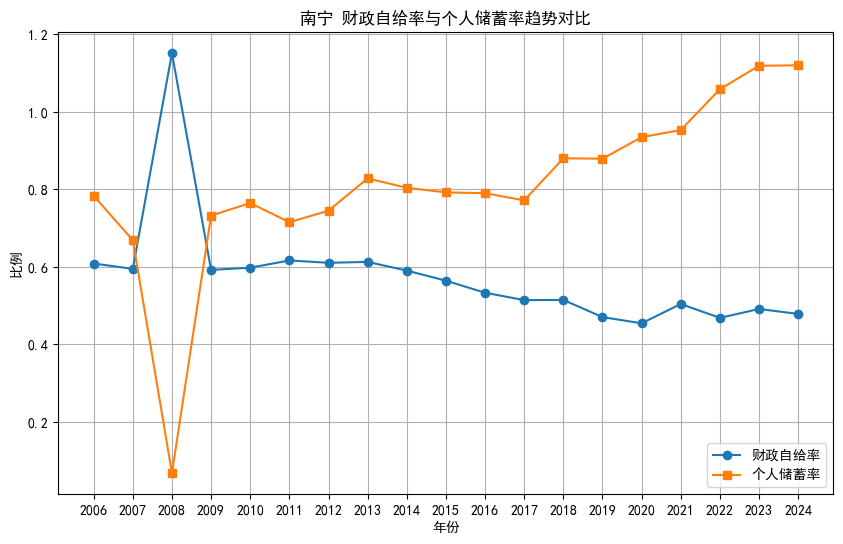

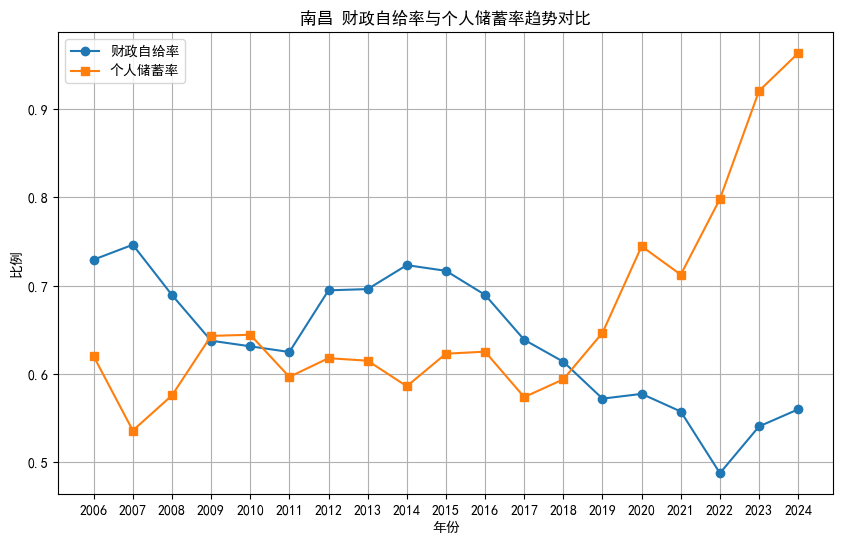

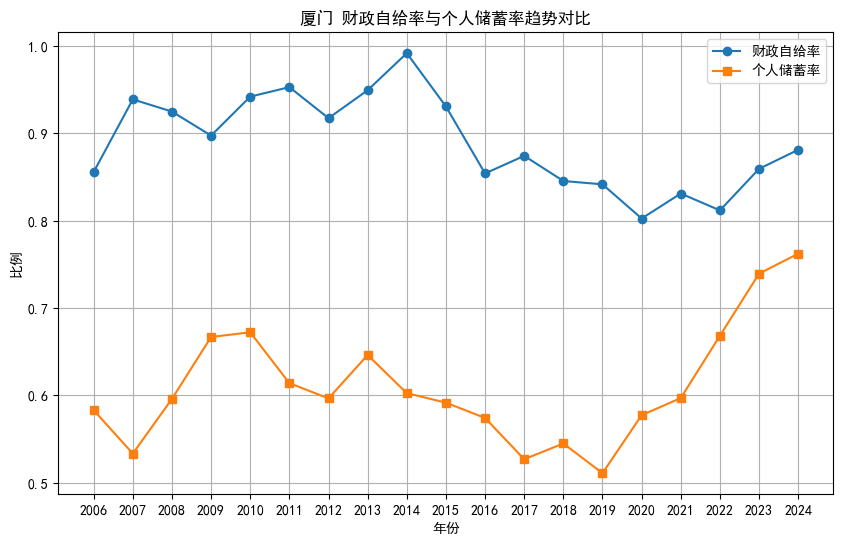

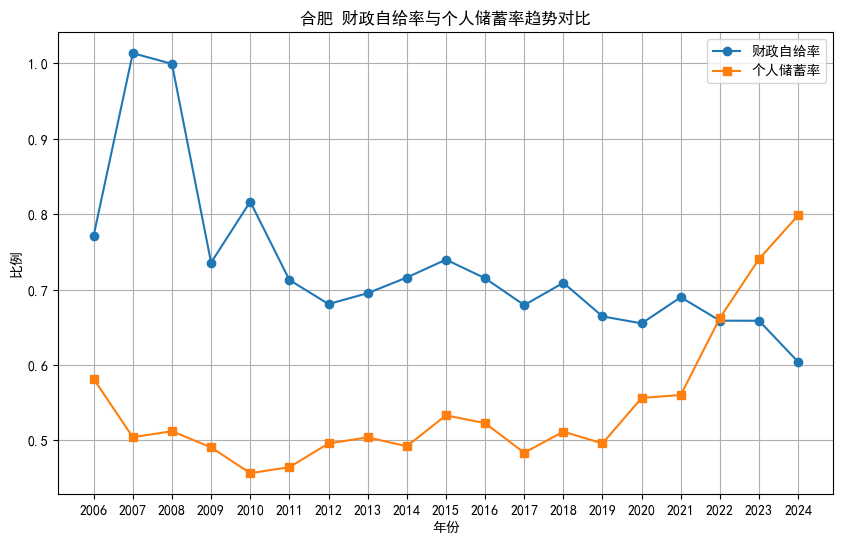

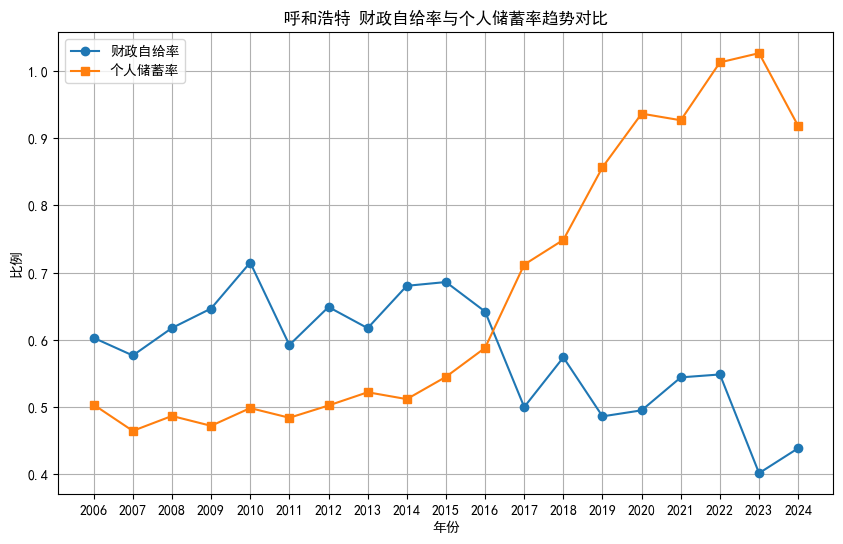

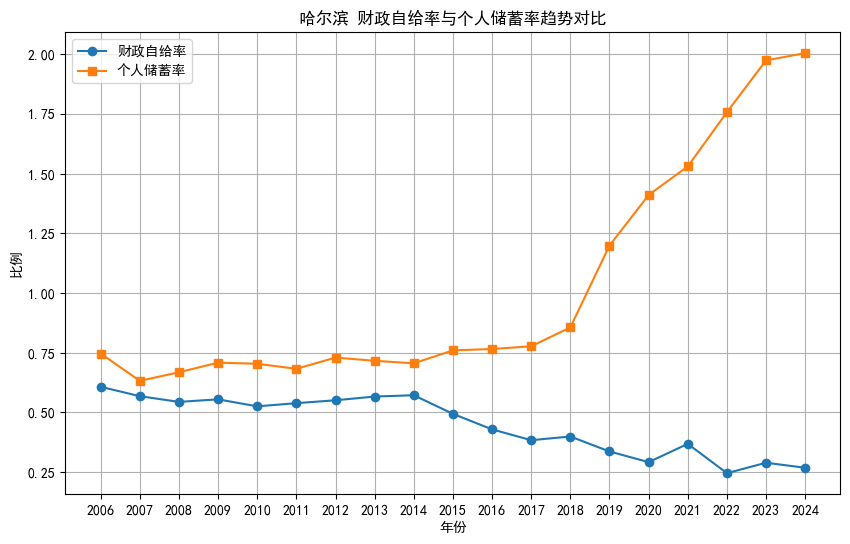

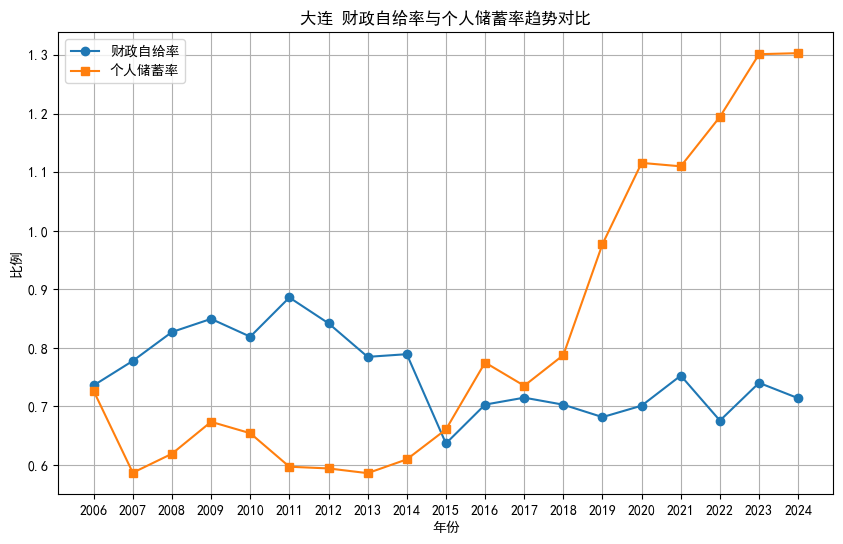

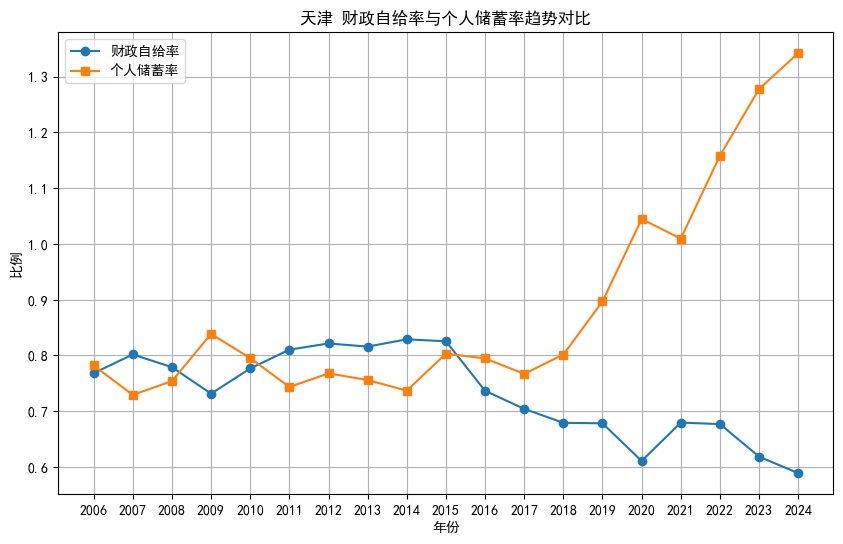

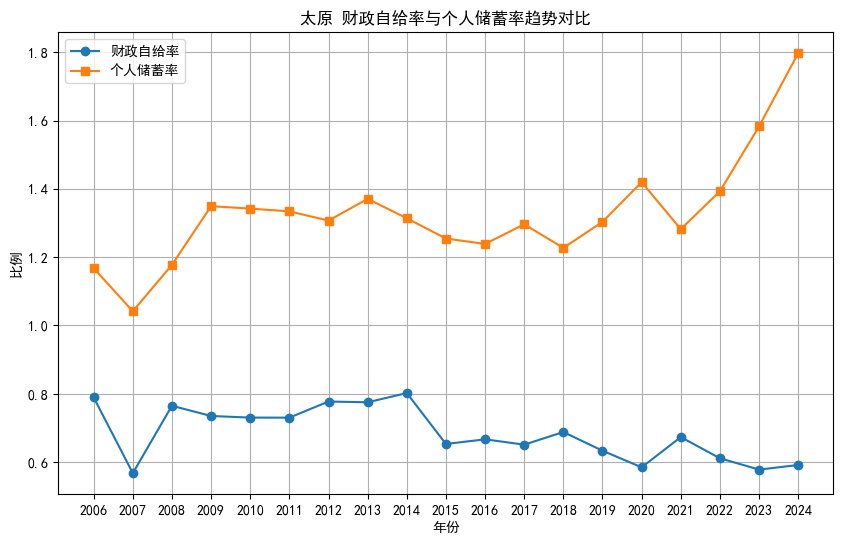

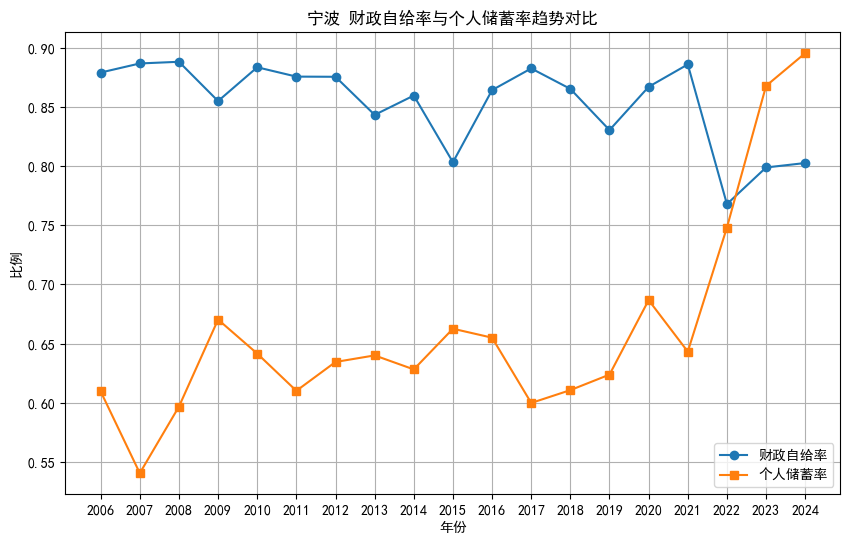

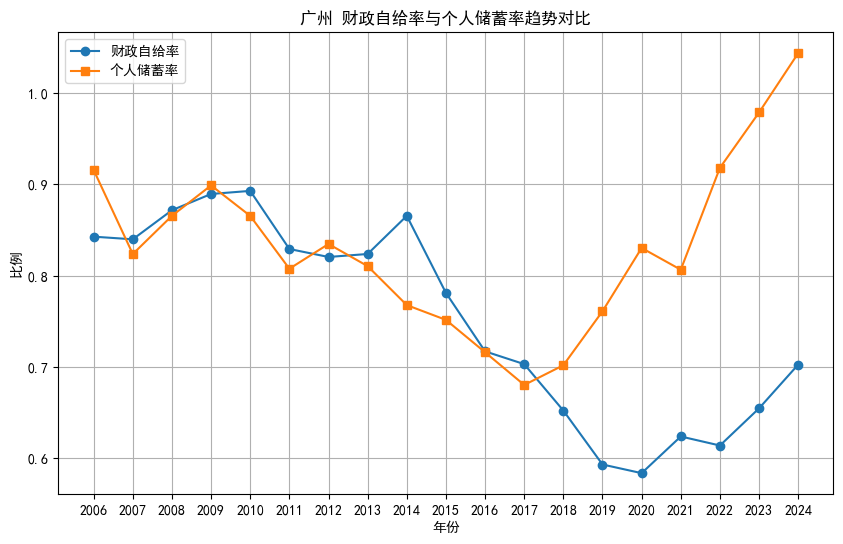

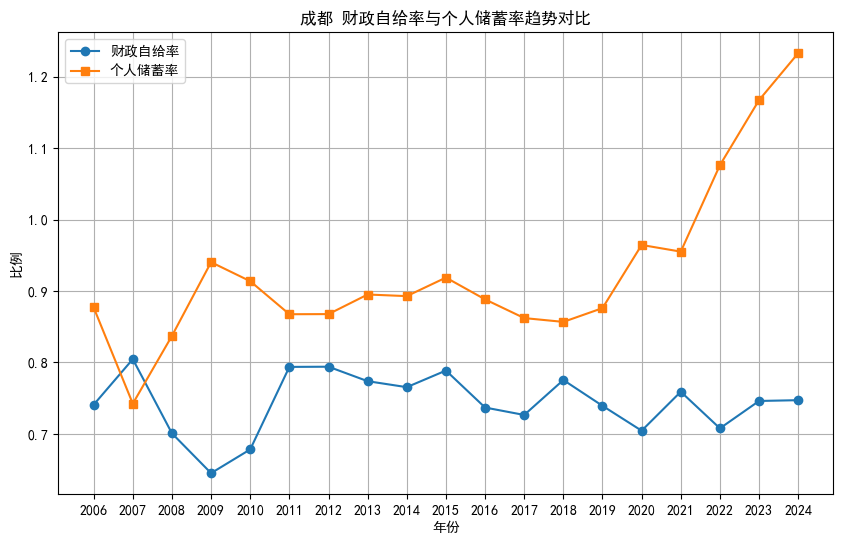

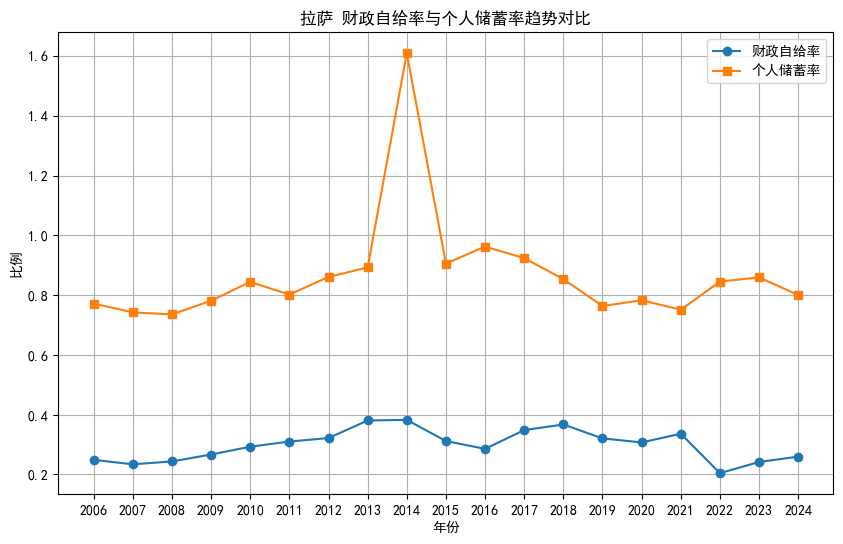

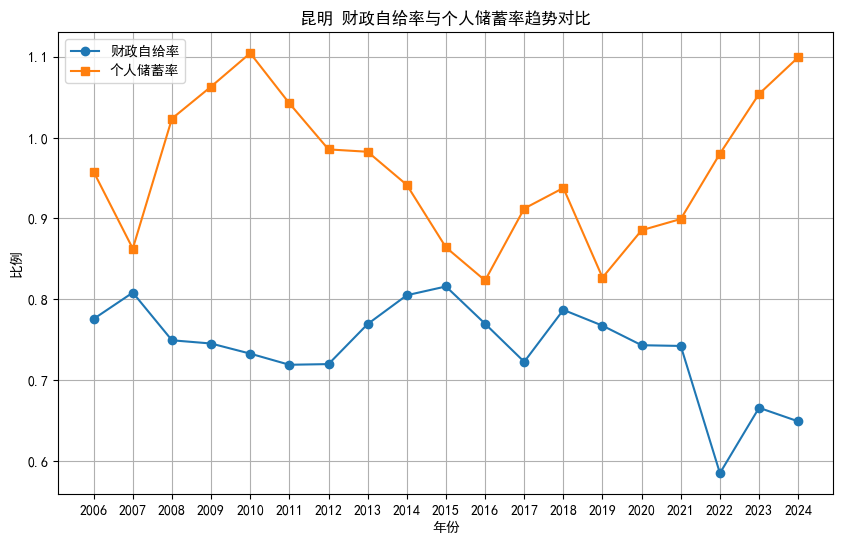

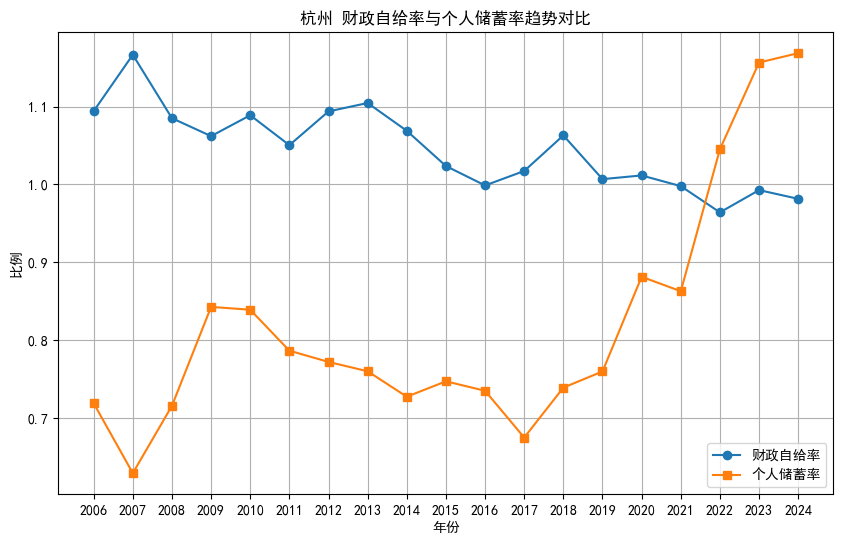

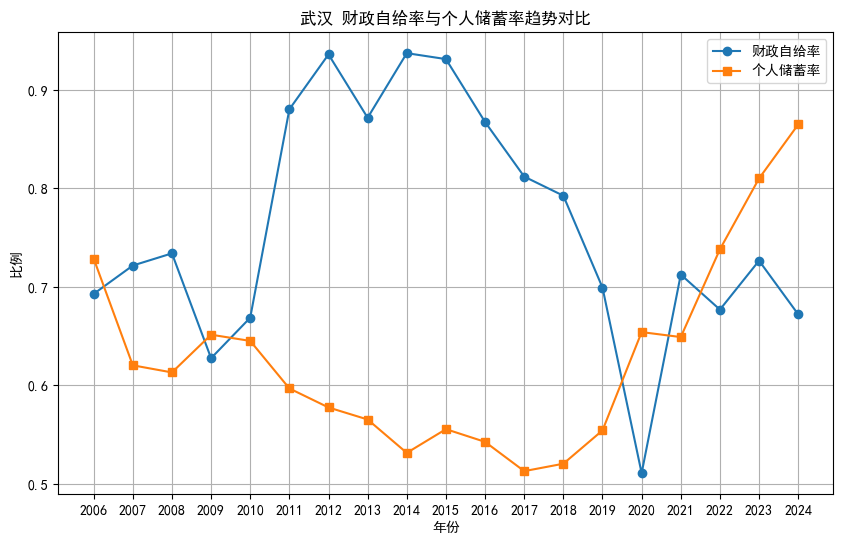

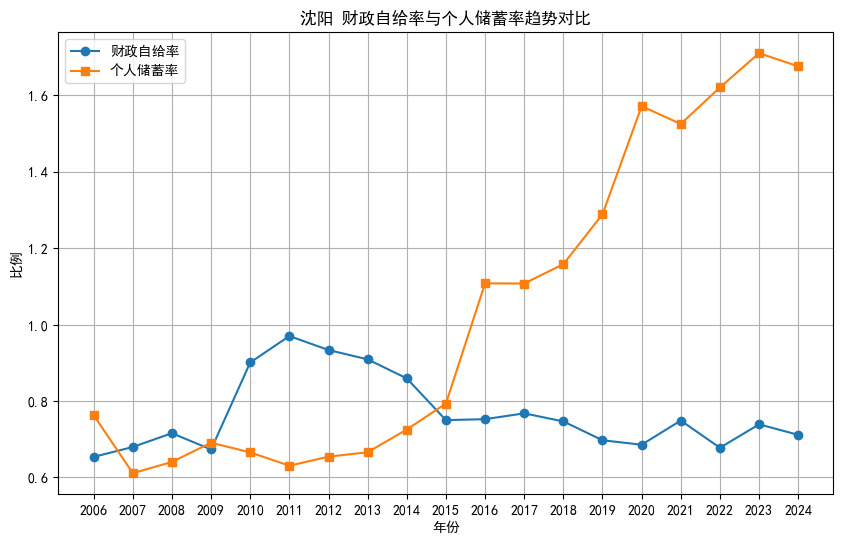

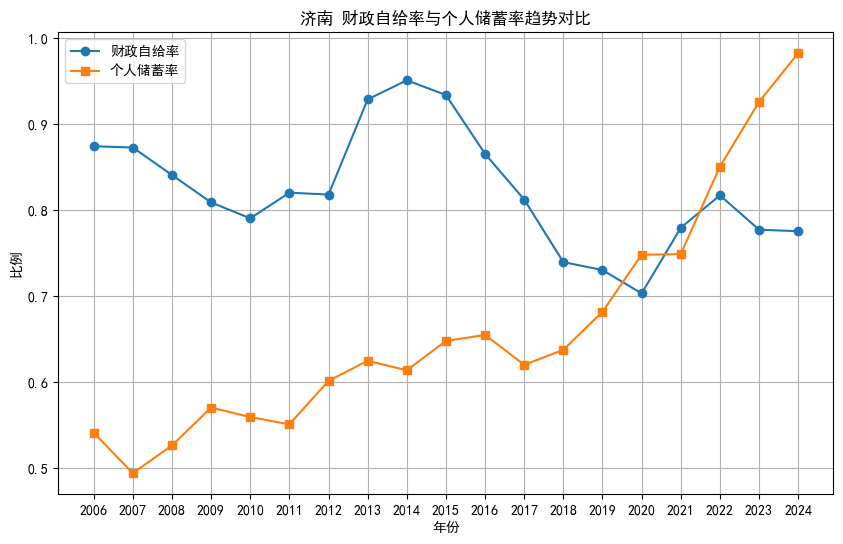

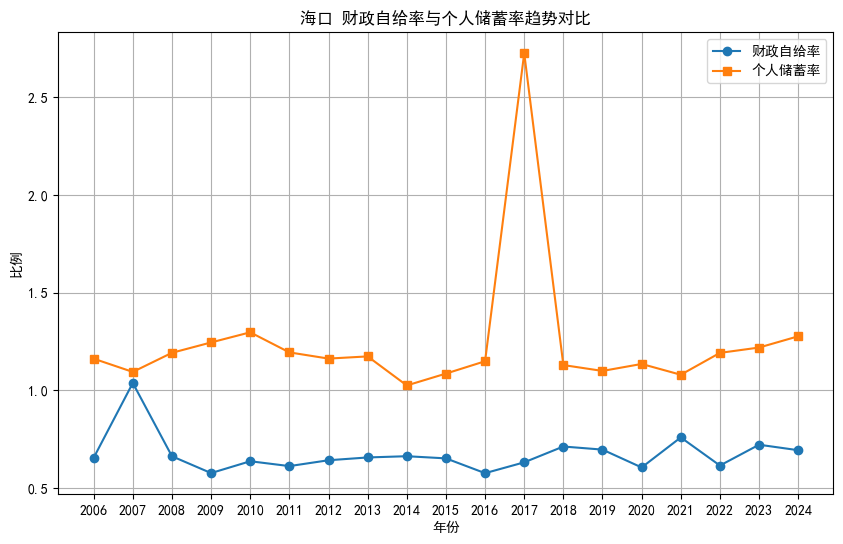

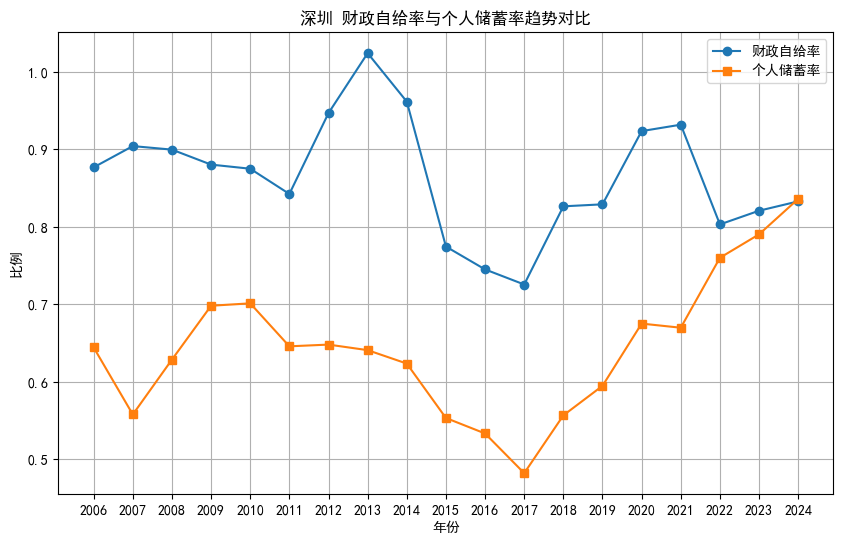

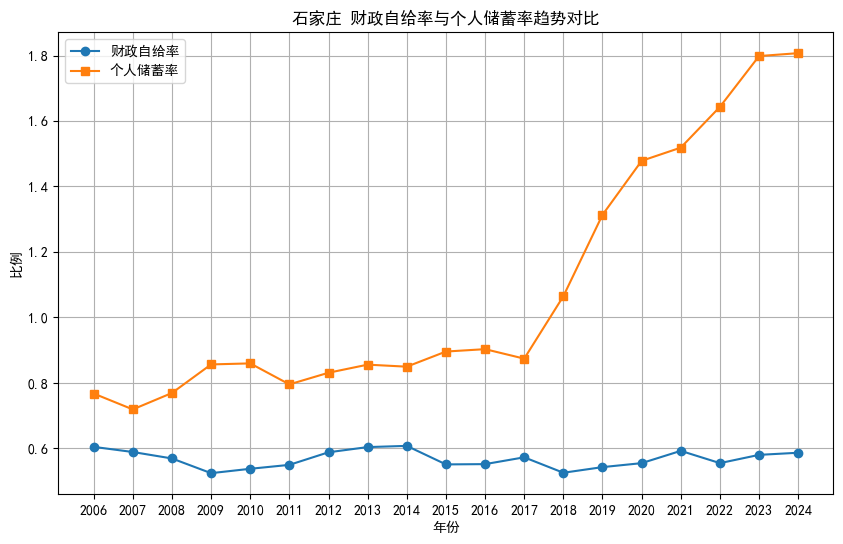

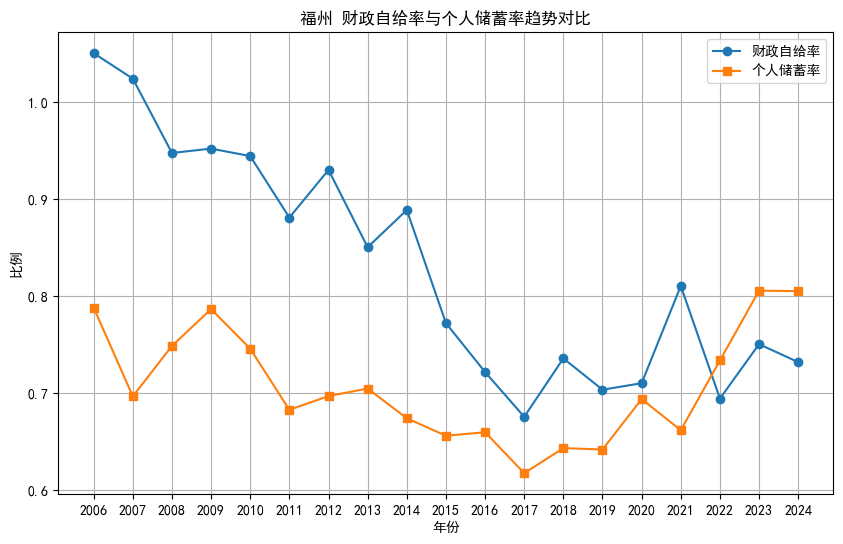

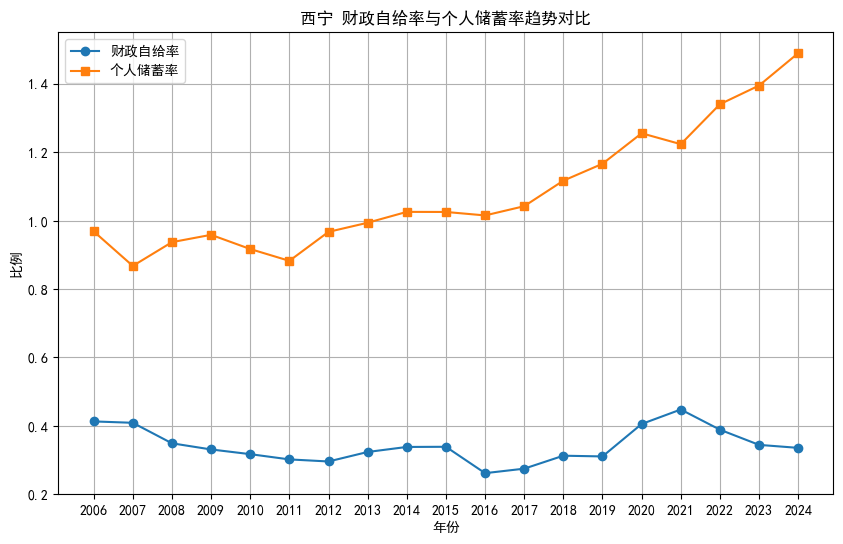

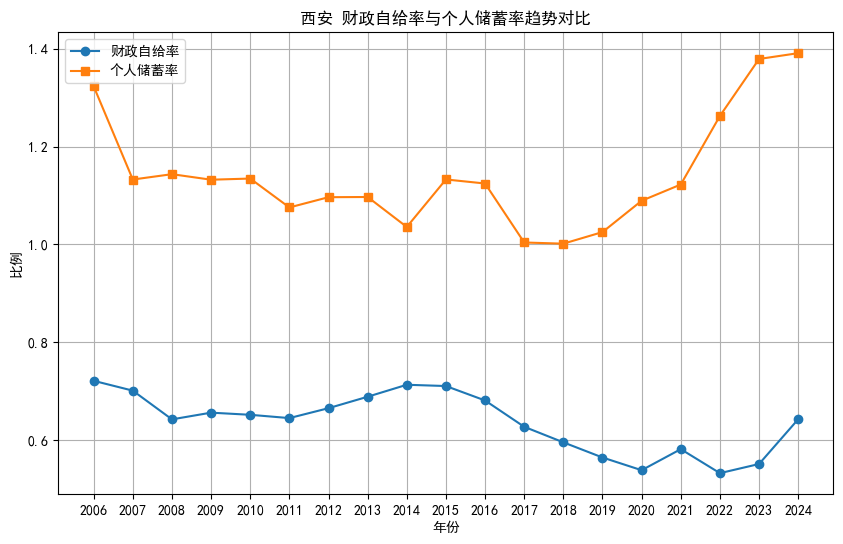

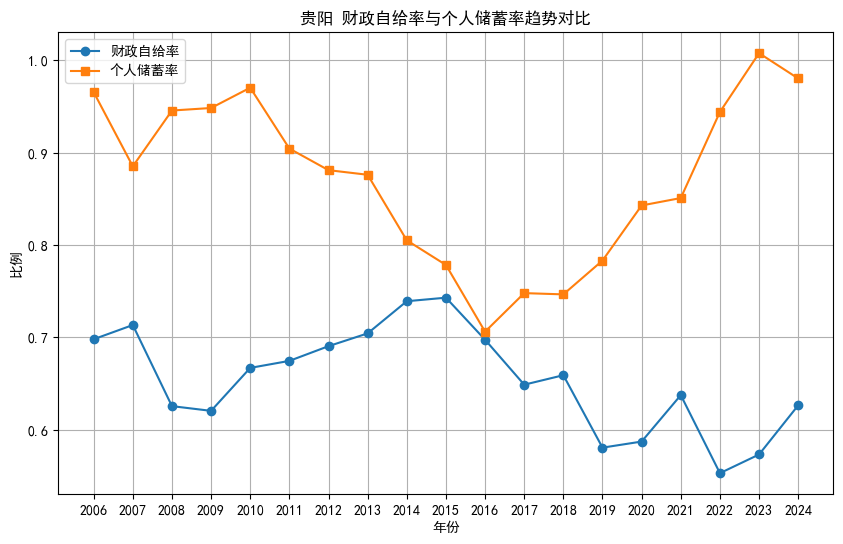

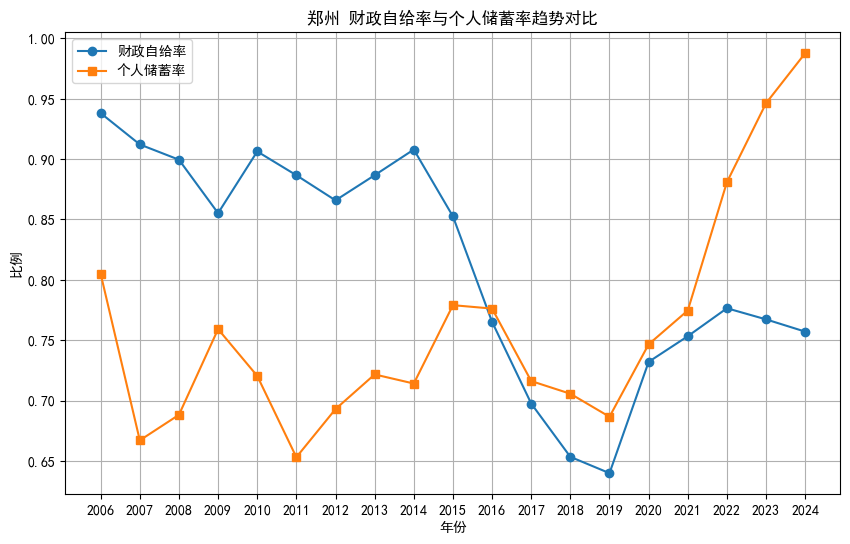

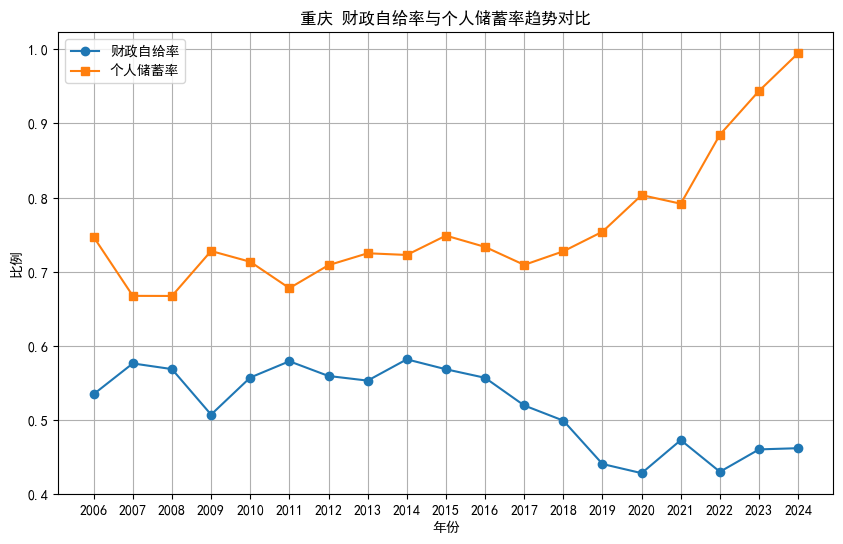

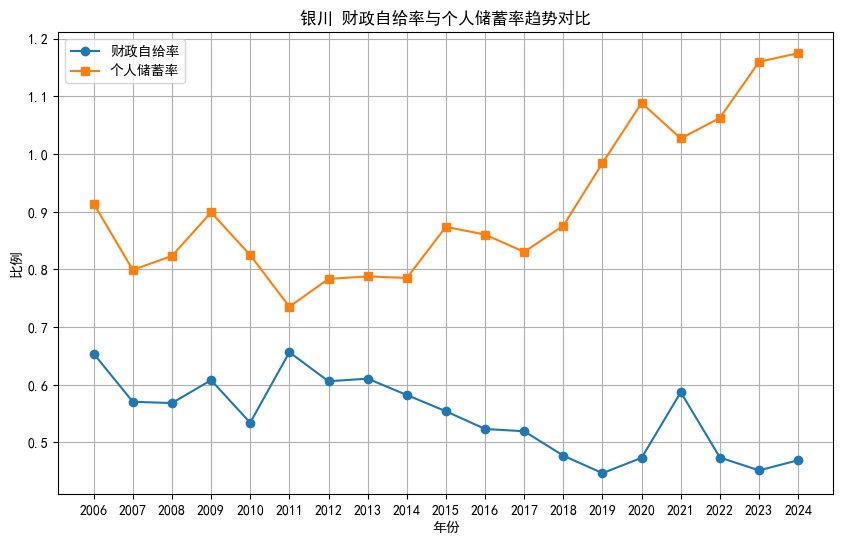

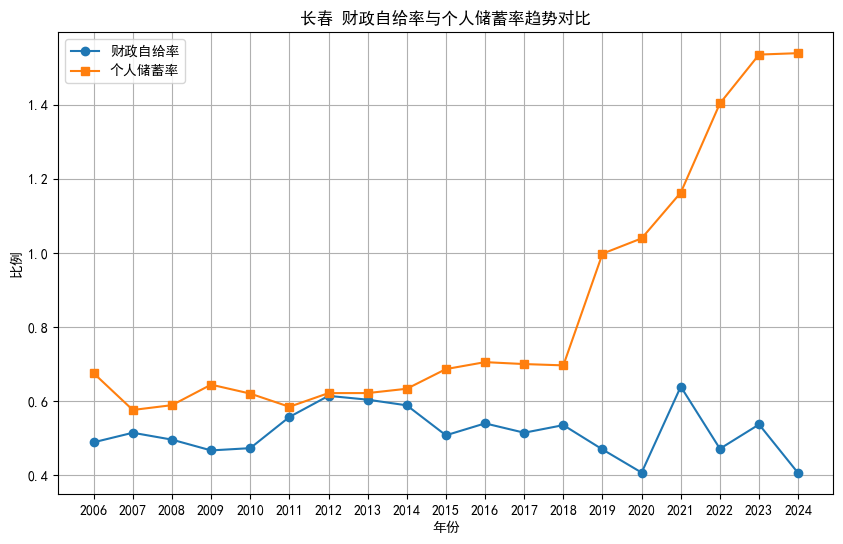

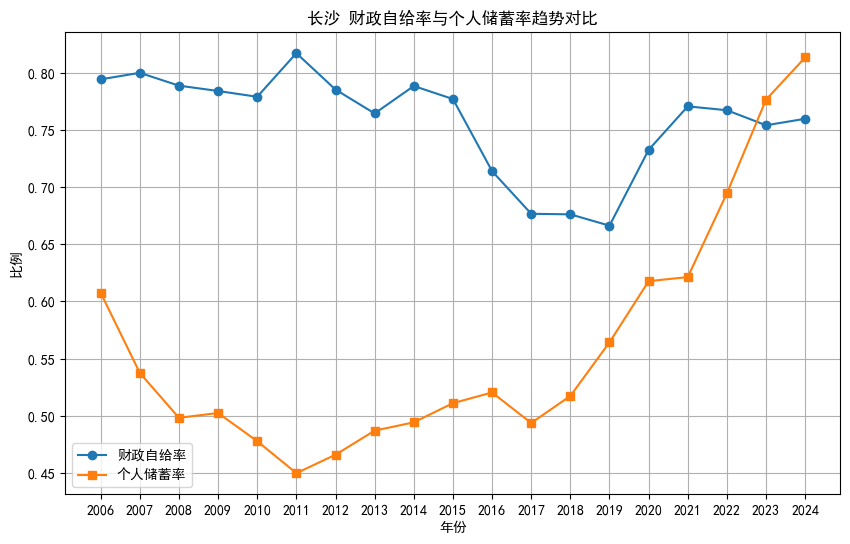

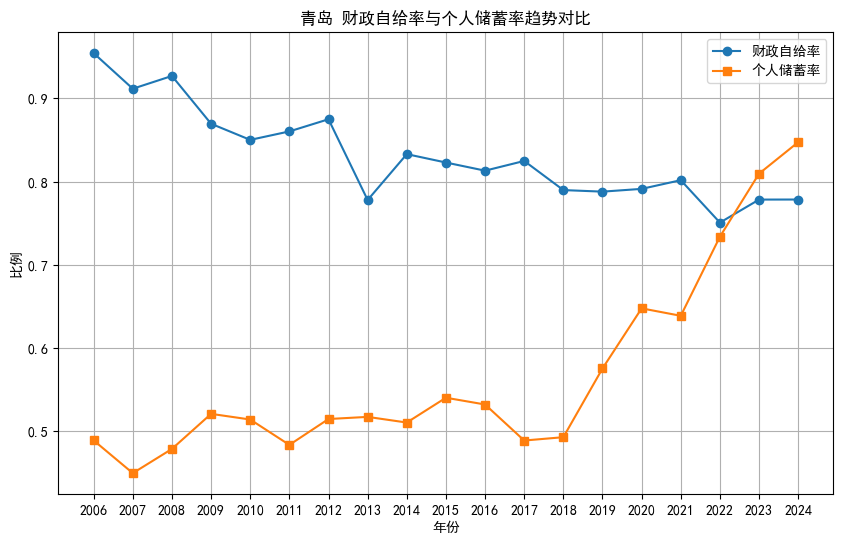

In [1]:
# 导入分析所需的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 新手必看：解决中文显示问题 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文（黑体）
plt.rcParams['axes.unicode_minus'] = False    # 显示负号
plt.rcParams['figure.figsize'] = (12, 8)      # 图表默认大小

# ========== 读取数据 ==========
data_path = './data_clean/city_data_long_final.csv'
df = pd.read_csv(data_path)
print("✅ 数据df已加载成功！数据形状：", df.shape)
print(df.describe())

# 计算财政自给率和个人储蓄率
df['财政自给率'] = df['收入'] / df['支出']
df['个人储蓄率'] = df['存款'] / df['GDP']

# 每个城市绘制一张折线图，包含财政自给率和个人储蓄率的趋势对比
cities = df['城市'].unique()
for city in cities:
    city_data = df[df['城市'] == city]
    
    plt.figure(figsize=(10, 6))
    plt.plot(city_data['年份'], city_data['财政自给率'], marker='o', label='财政自给率')
    plt.plot(city_data['年份'], city_data['个人储蓄率'], marker='s', label='个人储蓄率')
    
    plt.title(f'{city} 财政自给率与个人储蓄率趋势对比')
    plt.xlabel('年份')
    plt.ylabel('比例')
    plt.xticks(city_data['年份'])
    plt.legend()
    plt.grid()
    plt.show()



In [2]:
# 导入分析所需的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 新手必看：解决中文显示问题 ==========
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文（黑体）
plt.rcParams['axes.unicode_minus'] = False    # 显示负号
plt.rcParams['figure.figsize'] = (12, 8)      # 图表默认大小

# ========== 读取数据 ==========
data_path = './data_clean/city_data_long_final.csv'
df = pd.read_csv(data_path)
print("✅ 数据df已加载成功！数据形状：", df.shape)
print(df.describe())

# 分城市用KNN方法检测异常值
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings('ignore')  # 可选：忽略警告（如果不想看到警告信息）
print("KNN方法检测到异常值结果：")

def detect_outliers_knn(df, column):
    """使用KNN方法检测异常值，返回异常值所在行。"""
    n_samples = len(df)
    
    # 根据样本量动态设置n_neighbors
    # 确保 n_neighbors <= n_samples - 1
    n_neighbors = min(20, n_samples - 1) if n_samples > 3 else 3
    
    if n_samples <= 3:  # 样本太少，不适合做LOF
        print(f"  警告：{df['城市'].iloc[0]}的{column}数据样本量({n_samples})太少，跳过检测")
        return pd.DataFrame()  # 返回空DataFrame
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors)
    outlier_labels = lof.fit_predict(df[[column]])
    
    return df[outlier_labels == -1]

print("KNN方法检测到的异常值：")
for city in df['城市'].unique():
    city_data = df[df['城市'] == city]
    print(f"\n处理城市：{city} (样本量：{len(city_data)})")
    
    for col in ["收入", "支出", "存款", "GDP"]:
        outliers = detect_outliers_knn(city_data, col)
        print(f"  指标：{col}，异常值行数：{len(outliers)}")
        if not outliers.empty:
            print(outliers[["城市", "年份", col]])

# 分城市用IQR方法检测异常值
print("\nIQR方法检测到异常值结果：")
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)] 
for city in df['城市'].unique():
    city_data = df[df['城市'] == city]
    print(f"\n处理城市：{city} (样本量：{len(city_data)})")
    
    for col in ["收入", "支出", "存款", "GDP"]:
        outliers = detect_outliers_iqr(city_data, col)
        print(f"  指标：{col}，异常值行数：{len(outliers)}")
        if not outliers.empty:
            print(outliers[["城市", "年份", col]])

# 分城市用Z-score方法检测异常值
print("\nZ-score方法检测到异常值结果：")
def detect_outliers_zscore(df, column, threshold=3):
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    return df[np.abs(z_scores) > threshold]
for city in df['城市'].unique():
    city_data = df[df['城市'] == city]
    print(f"\n处理城市：{city} (样本量：{len(city_data)})")
    
    for col in ["收入", "支出", "存款", "GDP"]:
        outliers = detect_outliers_zscore(city_data, col)
        print(f"  指标：{col}，异常值行数：{len(outliers)}")
        if not outliers.empty:
            print(outliers[["城市", "年份", col]])

# 分城市用moving average方法检测异常值
print("\nMoving Average方法检测到异常值结果：")
def detect_outliers_moving_average(df, column, window=3, threshold=2):
    df = df.sort_values('年份')  # 确保按年份排序
    rolling_mean = df[column].rolling(window=window, center=True).mean()
    rolling_std = df[column].rolling(window=window, center=True).std()
    outliers = df[(df[column] > rolling_mean + threshold * rolling_std) | 
                  (df[column] < rolling_mean - threshold * rolling_std)]
    return outliers
for city in df['城市'].unique():
    city_data = df[df['城市'] == city]
    print(f"\n处理城市：{city} (样本量：{len(city_data)})")
    
    for col in ["收入", "支出", "存款", "GDP"]:
        outliers = detect_outliers_moving_average(city_data, col)
        print(f"  指标：{col}，异常值行数：{len(outliers)}")
        if not outliers.empty:
            print(outliers[["城市", "年份", col]])

✅ 数据df已加载成功！数据形状： (684, 6)
                年份           收入           支出            存款           GDP
count   684.000000   684.000000   684.000000    684.000000    684.000000
mean   2015.000000   895.285219  1199.533670   6935.635775   8096.285117
std       5.481234  1238.984447  1527.399479   8555.346408   8531.657210
min    2006.000000     3.900000    15.690000     78.990000    102.390000
25%    2010.000000   218.915000   341.292500   2018.815000   2600.690000
50%    2015.000000   461.320000   728.885000   4156.625000   5479.550000
75%    2020.000000  1013.392500  1340.912500   8507.737500  10573.702500
max    2024.000000  8374.170000  9874.840000  70398.150000  53759.500000
KNN方法检测到异常值结果：
KNN方法检测到的异常值：

处理城市：上海 (样本量：19)
  指标：收入，异常值行数：0
  指标：支出，异常值行数：0
  指标：存款，异常值行数：0
  指标：GDP，异常值行数：0

处理城市：乌鲁木齐 (样本量：19)
  指标：收入，异常值行数：0
  指标：支出，异常值行数：0
  指标：存款，异常值行数：0
  指标：GDP，异常值行数：0

处理城市：兰州 (样本量：19)
  指标：收入，异常值行数：0
  指标：支出，异常值行数：0
  指标：存款，异常值行数：0
  指标：GDP，异常值行数：0

处理城市：北京 (样本量：19)
  指标：收入，异常值行数：0
  